# Final CME Candidate Selection and CACTus Validation

This notebook identifies short-duration CME-like transients from the CIR-cleaned DSN scintillation signal and evaluates whether the resulting candidates are consistent with independently detected CACTus CME events.

The workflow combines transient thresholding, candidate merging, local background diagnostics, line-of-sight geometry, and CACTus propagation consistency checks to construct the final DSN CME candidate catalogue.

---

## Workflow

### SECTION 1 — Load CIR-Cleaned DSN Scintillation Windows

1. Load CIR-cleaned phase scintillation windows
2. Validate required columns
3. Sort windows chronologically
4. Inspect clean-signal statistics

---

### SECTION 2 — Add Line-of-Sight Geometry

1. Construct Earth–VEX geometry grid
2. Compute projected pierce-point geometry
3. Interpolate geometry onto DSN windows
4. Inspect pierce-point distance, longitude, and latitude

---

### SECTION 3 — Detect Final CME-Like Candidates

1. Apply transient threshold to CIR-cleaned signal
2. Identify consecutive elevated windows
3. Enforce duration constraints
4. Merge nearby transient intervals
5. Compute event-level geometry summaries

---

### SECTION 4 — Candidate / Background Diagnostics

1. Compute local event/background contrast
2. Measure candidate duration statistics
3. Compute peak and median clean-signal metrics
4. Evaluate candidate consistency

---

### SECTION 5 — CACTus CME Consistency Check

1. Load yearly CACTus CME catalogue
2. Propagate CACTus events radially
3. Compare CME fronts with event pierce-point distance
4. Evaluate angular consistency
5. Flag DSN candidates consistent with CACTus events

---

### SECTION 6 — Export PRIDE Validation Table

1. Select DSN/CACTus event columns needed for PRIDE comparison
2. Save CACTus-matched candidate table
3. Inspect exported validation table

---

### SECTION 7 — Final Candidate Visualisation

1. Plot CIR-cleaned DSN response
2. Overlay transient candidate intervals
3. Highlight CACTus-supported events
4. Compare supported and unsupported candidate populations

---

### SECTION 8 — Save Final Candidate Products

1. Save final CME candidate table
2. Save candidate/background diagnostic table
3. Save final candidate figure

---

## Outputs

This notebook produces:

- `final_cme_candidates_<year>.csv`
- `final_cme_candidate_contrast_<year>.csv`
- `dsn_cactus_events_for_pride_<year>.csv`
- `final_cme_candidates_<year>.png`

These outputs form the final transient-event catalogue used for PRIDE validation and multi-year statistical analysis.

In [1]:
# ============================================================
# SECTION 0 — Setup
# ============================================================

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# ============================================================
# Configuration
# ============================================================

YEAR = "2010"

debug = True
save_files = False

settings = importlib.import_module(f"config.settings_{YEAR}")

for k in dir(settings):
    if not k.startswith("_"):
        globals()[k] = getattr(settings, k)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / YEAR

INPUT_FILE = OUTPUT_DIR / f"phase_windows_detected_{YEAR}.csv"
OUTPUT_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.csv"
CHECK_FILE = OUTPUT_DIR / f"final_cme_candidate_contrast_{YEAR}.csv"
FIG_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.png"
EVENTS_FOR_PRIDE_FILE = OUTPUT_DIR / f"dsn_cactus_events_for_pride_{YEAR}.csv"

CACTUS_FILE = PROJECT_ROOT / "inputs" / f"cactus_cmes_{YEAR}.csv"

from src.geometry_utils import (
    build_vex_earth_p_point_geometry_grid,
    add_projected_p_point_geometry,
)

from src.detection_utils import (
    FinalCMEConfig,
    load_final_cme_input,
    detect_final_cme_candidates,
    compute_final_cme_contrast,
    add_event_median_columns,
    match_cactus_to_dsn_candidates,
)

from src.plot_utils import plot_final_cme_candidates

if debug:
    print("YEAR:", YEAR)
    print("PROJECT_ROOT:", PROJECT_ROOT)
    print("OUTPUT_DIR:", OUTPUT_DIR)
    print("INPUT_FILE:", INPUT_FILE)
    print("CACTUS_FILE:", CACTUS_FILE)

YEAR: 2010
PROJECT_ROOT: /mnt/data/jhub/16-VenusExpres/dsn_multi_year
OUTPUT_DIR: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010
INPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/phase_windows_detected_2010.csv
CACTUS_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/inputs/cactus_cmes_2010.csv


In [3]:
# ============================================================
# SECTION 1 — Final CME-Candidate Settings
# ============================================================

final_cme_config = FinalCMEConfig(
    threshold=3.0,
    min_consec_windows=2,
    min_duration_hr=0.33,
    max_duration_hr=12.0,
    merge_gap_hr=0.67,
    local_background_hr=12.0,
)

if debug:
    print(final_cme_config)

FinalCMEConfig(threshold=3.0, min_consec_windows=2, min_duration_hr=0.33, max_duration_hr=12.0, merge_gap_hr=0.67, local_background_hr=12.0)


In [4]:
# ============================================================
# SECTION 2 — Load CIR-Cleaned DSN Window Table
# ============================================================

windows_df = load_final_cme_input(INPUT_FILE)

if debug:
    print("Rows:", len(windows_df))
    print("Time range:", windows_df["mid"].min(), "→", windows_df["mid"].max())
    print(
        "Clean signal range:",
        windows_df["clean_signal"].min(),
        "→",
        windows_df["clean_signal"].max(),
    )

    display(windows_df.head())

Rows: 14590
Time range: 2010-01-01 09:47:20 → 2010-12-30 12:27:20
Clean signal range: 0.1512860628293095 → 129.27815654819366


,start,end,mid,phase_rms_rad,n_samples,day,elongation_deg,phase_expected,phase_ratio,phase_smooth,clean_signal,event_flag
0,2010-01-01 09:37:20,2010-01-01 09:57:20,2010-01-01 09:47:20,14.885682,120,2010-01-01,2.6407,12.796661,1.163247,1.191859,0.975994,False
1,2010-01-01 09:47:20,2010-01-01 10:07:20,2010-01-01 09:57:20,15.971841,120,2010-01-01,2.6407,12.796661,1.248126,1.163247,1.072967,False
2,2010-01-01 09:57:20,2010-01-01 10:17:20,2010-01-01 10:07:20,8.508995,120,2010-01-01,2.6407,12.796661,0.664939,1.191859,0.557900,False
3,2010-01-01 10:07:20,2010-01-01 10:27:20,2010-01-01 10:17:20,6.813039,120,2010-01-01,2.6407,12.796661,0.532408,1.220471,0.436231,False
4,2010-01-01 10:17:20,2010-01-01 10:37:20,2010-01-01 10:27:20,9.688446,120,2010-01-01,2.6407,12.796661,0.757107,1.191859,0.635232,False


In [5]:
# ============================================================
# SECTION 3 — Add LOS Closest-Approach Geometry
# ============================================================

geom_start = windows_df["mid"].min() - pd.Timedelta(hours=1)
geom_stop = windows_df["mid"].max() + pd.Timedelta(hours=1)

geom_grid = build_vex_earth_p_point_geometry_grid(
    start=geom_start,
    stop=geom_stop,
    step="10m",
)

windows_df = add_projected_p_point_geometry(
    windows_df,
    geom_grid,
    mid_col="mid",
)

if debug:
    print("Geometry rows:", len(geom_grid))
    print(
        "Geometry time range:",
        geom_grid["time"].min(),
        "→",
        geom_grid["time"].max(),
    )

    print(
        "P-point range AU:",
        windows_df["p_point_AU"].min(),
        "→",
        windows_df["p_point_AU"].max(),
    )

    print(
        "P-point longitude range:",
        windows_df["p_lon_deg"].min(),
        "→",
        windows_df["p_lon_deg"].max(),
    )

    print(
        "P-point latitude range:",
        windows_df["p_lat_deg"].min(),
        "→",
        windows_df["p_lat_deg"].max(),
    )

    display(
        windows_df[
            ["mid", "p_point_AU", "p_lon_deg", "p_lat_deg", "los_length_AU"]
        ].head()
    )

Geometry rows: 52301
Geometry time range: 2010-01-01 08:47:20+00:00 → 2010-12-30 13:27:20+00:00
P-point range AU: 0.018550575729632476 → 0.7284020012577529
P-point longitude range: 0.9085666234420842 → 359.6982940086496
P-point latitude range: -56.278714710279694 → 2.8895635728981253


,mid,p_point_AU,p_lon_deg,p_lat_deg,los_length_AU
0,2010-01-01 09:47:20+00:00,0.043554,188.146018,-10.464637,1.708452
1,2010-01-01 09:57:20+00:00,0.043528,188.154469,-10.484377,1.708454
2,2010-01-01 10:07:20+00:00,0.043502,188.162924,-10.503905,1.708457
3,2010-01-01 10:17:20+00:00,0.043476,188.171380,-10.523228,1.708459
4,2010-01-01 10:27:20+00:00,0.043450,188.179840,-10.542355,1.708461


In [7]:
# ============================================================
# SECTION 4 — Detect Final CME-Like Candidates
# ============================================================

windows_flagged, final_events = detect_final_cme_candidates(
    windows_df,
    year=YEAR,
    config=final_cme_config,
)

windows_flagged["mid"] = pd.to_datetime(
    windows_flagged["mid"],
    utc=True,
)

windows_df["mid"] = pd.to_datetime(
    windows_df["mid"],
    utc=True,
)

for c in ["start", "end", "mid"]:
    if c in final_events.columns:
        final_events[c] = pd.to_datetime(
            final_events[c],
            utc=True,
        )

if debug:
    print("Final CME-like candidates:", len(final_events))
    display(final_events)

# ============================================================
# SECTION 4.5 — Add Event-Level Geometry Summaries
# ============================================================

final_events = add_event_median_columns(
    final_events,
    windows_df,
    columns=[
        "p_point_AU",
        "p_lon_deg",
        "p_lat_deg",
    ],
)

if debug and not final_events.empty:
    display(
        final_events[
            [
                "event_id",
                "p_point_AU_median",
                "p_lon_deg_median",
                "p_lat_deg_median",
            ]
        ]
    )

Final CME-like candidates: 32


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,median_phase_rms_rad,elongation_deg_median,p_point_AU_median
0,1,2010,2010-02-23 05:57:20+00:00,2010-02-23 06:37:20+00:00,2010-02-23 06:17:20+00:00,0.666667,3,4.855846,3.175085,5.921438,3.865849,10.2293,0.176806
1,2,2010,2010-02-25 13:07:20+00:00,2010-02-25 13:57:20+00:00,2010-02-25 13:32:20+00:00,0.833333,4,7.073263,5.782677,25.919475,21.190213,10.7083,0.186236
2,3,2010,2010-02-27 05:57:20+00:00,2010-02-27 06:37:20+00:00,2010-02-27 06:17:20+00:00,0.666667,3,12.321122,9.799374,12.021557,8.905643,11.1880,0.193237
3,4,2010,2010-03-02 12:27:20+00:00,2010-03-02 14:07:20+00:00,2010-03-02 13:17:20+00:00,1.666667,4,5.890991,4.108528,21.734104,15.843103,11.9086,0.206656
4,5,2010,2010-03-07 08:57:20+00:00,2010-03-07 10:07:20+00:00,2010-03-07 09:32:20+00:00,1.166667,6,8.801972,6.547353,9.113606,6.779162,13.1120,0.226689
5,6,2010,2010-04-12 13:27:20+00:00,2010-04-12 13:57:20+00:00,2010-04-12 13:42:20+00:00,0.500000,2,4.401309,4.158418,3.705392,3.500906,21.8738,0.375734
6,7,2010,2010-04-13 04:57:20+00:00,2010-04-13 05:37:20+00:00,2010-04-13 05:17:20+00:00,0.666667,3,3.820378,3.154946,3.065988,2.531956,22.1187,0.378418
7,8,2010,2010-06-05 11:17:20+00:00,2010-06-05 11:47:20+00:00,2010-06-05 11:32:20+00:00,0.500000,2,4.052692,3.766941,4.957834,4.608263,34.7810,0.580390
8,9,2010,2010-06-15 12:57:20+00:00,2010-06-15 13:27:20+00:00,2010-06-15 13:12:20+00:00,0.500000,2,3.846101,3.811634,2.849122,2.823590,36.9698,0.612616
9,10,2010,2010-06-25 09:47:20+00:00,2010-06-25 10:27:20+00:00,2010-06-25 10:07:20+00:00,0.666667,3,4.128069,3.307911,1.868963,1.497641,39.0367,0.641418


,event_id,p_point_AU_median,p_lon_deg_median,p_lat_deg_median
0,1,0.176806,74.775347,-7.934604
1,2,0.186236,77.635137,-7.500221
2,3,0.193237,79.741837,-7.051307
3,4,0.206777,83.829778,-6.440415
4,5,0.226689,89.825310,-5.467872
5,6,0.375734,134.413607,-0.095398
6,7,0.378418,135.211701,0.019906
7,8,0.580390,199.502174,2.757588
8,9,0.612616,211.331652,2.625383
9,10,0.641418,222.781521,2.340834


In [9]:
# ============================================================
# SECTION 5 — Candidate / Background Diagnostics
# ============================================================

diagnostics_df = compute_final_cme_contrast(
    windows_flagged,
    final_events,
)

if debug:

    display(diagnostics_df.head(10))

    print(
        "Median contrast ratio:",
        diagnostics_df["contrast_ratio"].median(),
    )

    print(
        "Minimum contrast ratio:",
        diagnostics_df["contrast_ratio"].min(),
    )

    print(
        "Maximum contrast ratio:",
        diagnostics_df["contrast_ratio"].max(),
    )

,event_id,inside_median,outside_median,contrast_ratio
0,1,3.020749,0.932602,3.239055
1,2,4.577710,1.068764,4.283181
2,3,4.409979,0.995582,4.429549
3,4,2.801266,1.050198,2.667370
4,5,5.781130,0.999551,5.783728
5,6,3.005749,0.972499,3.090749
6,7,3.004509,0.882507,3.404516
7,8,3.223935,1.004717,3.208800
8,9,2.715000,1.013787,2.678079
9,10,3.127143,1.056232,2.960658


Median contrast ratio: 3.4792710205734005
Minimum contrast ratio: 2.165893141744152
Maximum contrast ratio: 33.017980901891676


In [10]:
# ============================================================
# SECTION 6 — Load CACTus Catalogue
# ============================================================

cactus_df = pd.read_csv(CACTUS_FILE)

cactus_df["t0"] = pd.to_datetime(
    cactus_df["t0"],
    utc=True,
    errors="coerce",
)

for c in ["start", "end", "mid"]:
    if c in final_events.columns:
        final_events[c] = pd.to_datetime(
            final_events[c],
            utc=True,
            errors="coerce",
        )

if debug:
    print("CACTus rows:", len(cactus_df))
    print("CACTus time range:", cactus_df["t0"].min(), "→", cactus_df["t0"].max())
    display(cactus_df.head())

CACTus rows: 492
CACTus time range: 2010-01-01 15:08:00+00:00 → 2010-12-31 13:36:00+00:00


,month,cme_id,t0,dt0_hr,pa_deg,da_deg,v_km_s,dv_km_s,minv_km_s,maxv_km_s,halo_flag,source_url
0,1,12,2010-01-18 23:49:00+00:00,0,258,18,1132,117,865,1196,NaN,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...
1,1,11,2010-01-18 20:49:00+00:00,2,100,66,363,115,197,598,NaN,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...
2,1,10,2010-01-17 04:06:00+00:00,2,96,90,437,194,271,950,NaN,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...
3,1,9,2010-01-15 01:27:00+00:00,4,80,22,166,190,117,724,NaN,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...
4,1,8,2010-01-10 07:31:00+00:00,1,73,12,265,91,128,321,NaN,https://www.sidc.be/cactus/catalog/LASCO/2_5_0...


In [11]:
# ============================================================
# SECTION 7 — CACTus Consistency Check
# ============================================================

if "los_pa_deg_median" in final_events.columns:
    EVENT_ANGLE_COL = "los_pa_deg_median"

elif "p_lon_deg_median" in final_events.columns:
    EVENT_ANGLE_COL = "p_lon_deg_median"

else:
    EVENT_ANGLE_COL = None

final_events = match_cactus_to_dsn_candidates(
    final_events,
    cactus_df,
    p_col="p_point_AU_median",
    event_angle_col=EVENT_ANGLE_COL,
    radial_tolerance_AU=0.20,
    angle_tolerance_deg=15.0,
)

if debug:
    print("Using event angle column:", EVENT_ANGLE_COL)

    print("\nCACTus crossing counts:")
    print(final_events["cactus_crosses_p_point"].value_counts(dropna=False))

    print("\nCACTus direction consistency counts:")
    print(final_events["cactus_direction_consistent"].value_counts(dropna=False))

    display(final_events)

Using event angle column: p_lon_deg_median

CACTus crossing counts:
cactus_crosses_p_point
False    17
True     15
Name: count, dtype: int64

CACTus direction consistency counts:
cactus_direction_consistent
False    17
True     15
Name: count, dtype: int64


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,matched_cactus_half_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,event_angle_deg,cactus_angle_error_deg,cactus_angle_allowed_deg
0,1,2010,2010-02-23 05:57:20+00:00,2010-02-23 06:37:20+00:00,2010-02-23 06:17:20+00:00,0.666667,3,4.855846,3.175085,5.921438,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2010,2010-02-25 13:07:20+00:00,2010-02-25 13:57:20+00:00,2010-02-25 13:32:20+00:00,0.833333,4,7.073263,5.782677,25.919475,...,2010-02-24 17:06:00+00:00,215.0,116.0,50.0,25.0,0.105748,0.080488,77.635137,38.364863,40.0
2,3,2010,2010-02-27 05:57:20+00:00,2010-02-27 06:37:20+00:00,2010-02-27 06:17:20+00:00,0.666667,3,12.321122,9.799374,12.021557,...,2010-02-24 17:06:00+00:00,215.0,116.0,50.0,25.0,0.316583,0.123346,79.741837,36.258163,40.0
3,4,2010,2010-03-02 12:27:20+00:00,2010-03-02 14:07:20+00:00,2010-03-02 13:17:20+00:00,1.666667,4,5.890991,4.108528,21.734104,...,2010-03-01 22:06:00+00:00,868.0,60.0,34.0,17.0,0.317265,0.110489,83.829778,23.829778,32.0
4,5,2010,2010-03-07 08:57:20+00:00,2010-03-07 10:07:20+00:00,2010-03-07 09:32:20+00:00,1.166667,6,8.801972,6.547353,9.113606,...,2010-03-06 08:27:00+00:00,538.0,114.0,30.0,15.0,0.324819,0.098130,89.825310,24.174690,30.0
5,6,2010,2010-04-12 13:27:20+00:00,2010-04-12 13:57:20+00:00,2010-04-12 13:42:20+00:00,0.500000,2,4.401309,4.158418,3.705392,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,2010,2010-04-13 04:57:20+00:00,2010-04-13 05:37:20+00:00,2010-04-13 05:17:20+00:00,0.666667,3,3.820378,3.154946,3.065988,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,2010,2010-06-05 11:17:20+00:00,2010-06-05 11:47:20+00:00,2010-06-05 11:32:20+00:00,0.500000,2,4.052692,3.766941,4.957834,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,2010,2010-06-15 12:57:20+00:00,2010-06-15 13:27:20+00:00,2010-06-15 13:12:20+00:00,0.500000,2,3.846101,3.811634,2.849122,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,2010,2010-06-25 09:47:20+00:00,2010-06-25 10:27:20+00:00,2010-06-25 10:07:20+00:00,0.666667,3,4.128069,3.307911,1.868963,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# ============================================================
# SECTION 8 — Save DSN/CACTus-Matched Events for PRIDE
# ============================================================

cols_for_pride = [
    "event_id",
    "year",
    "start",
    "end",
    "mid",
    "duration_hr",
    "n_windows",
    "peak_clean_signal",
    "median_clean_signal",
    "peak_phase_rms_rad",
    "p_point_AU_median",
    "event_angle_deg",
    "cactus_crosses_p_point",
    "cactus_direction_consistent",
    "matched_cactus_launch_utc",
    "matched_cactus_speed_kms",
    "matched_cactus_pa_deg",
    "matched_cactus_width_deg",
    "cactus_predicted_distance_AU",
    "cactus_radial_error_AU",
    "cactus_angle_error_deg",
    "cactus_angle_allowed_deg",
]

cols_for_pride = [
    c for c in cols_for_pride
    if c in final_events.columns
]

events_for_pride = final_events[cols_for_pride].copy()

if save_files:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    events_for_pride.to_csv(
        EVENTS_FOR_PRIDE_FILE,
        index=False,
    )

    print("Saved:", EVENTS_FOR_PRIDE_FILE)

display(events_for_pride)

,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,cactus_crosses_p_point,cactus_direction_consistent,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,cactus_angle_error_deg,cactus_angle_allowed_deg
0,1,2010,2010-02-23 05:57:20+00:00,2010-02-23 06:37:20+00:00,2010-02-23 06:17:20+00:00,0.666667,3,4.855846,3.175085,5.921438,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2010,2010-02-25 13:07:20+00:00,2010-02-25 13:57:20+00:00,2010-02-25 13:32:20+00:00,0.833333,4,7.073263,5.782677,25.919475,...,True,True,2010-02-24 17:06:00+00:00,215.0,116.0,50.0,0.105748,0.080488,38.364863,40.0
2,3,2010,2010-02-27 05:57:20+00:00,2010-02-27 06:37:20+00:00,2010-02-27 06:17:20+00:00,0.666667,3,12.321122,9.799374,12.021557,...,True,True,2010-02-24 17:06:00+00:00,215.0,116.0,50.0,0.316583,0.123346,36.258163,40.0
3,4,2010,2010-03-02 12:27:20+00:00,2010-03-02 14:07:20+00:00,2010-03-02 13:17:20+00:00,1.666667,4,5.890991,4.108528,21.734104,...,True,True,2010-03-01 22:06:00+00:00,868.0,60.0,34.0,0.317265,0.110489,23.829778,32.0
4,5,2010,2010-03-07 08:57:20+00:00,2010-03-07 10:07:20+00:00,2010-03-07 09:32:20+00:00,1.166667,6,8.801972,6.547353,9.113606,...,True,True,2010-03-06 08:27:00+00:00,538.0,114.0,30.0,0.324819,0.098130,24.174690,30.0
5,6,2010,2010-04-12 13:27:20+00:00,2010-04-12 13:57:20+00:00,2010-04-12 13:42:20+00:00,0.500000,2,4.401309,4.158418,3.705392,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,2010,2010-04-13 04:57:20+00:00,2010-04-13 05:37:20+00:00,2010-04-13 05:17:20+00:00,0.666667,3,3.820378,3.154946,3.065988,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,2010,2010-06-05 11:17:20+00:00,2010-06-05 11:47:20+00:00,2010-06-05 11:32:20+00:00,0.500000,2,4.052692,3.766941,4.957834,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,2010,2010-06-15 12:57:20+00:00,2010-06-15 13:27:20+00:00,2010-06-15 13:12:20+00:00,0.500000,2,3.846101,3.811634,2.849122,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,2010,2010-06-25 09:47:20+00:00,2010-06-25 10:27:20+00:00,2010-06-25 10:07:20+00:00,0.666667,3,4.128069,3.307911,1.868963,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


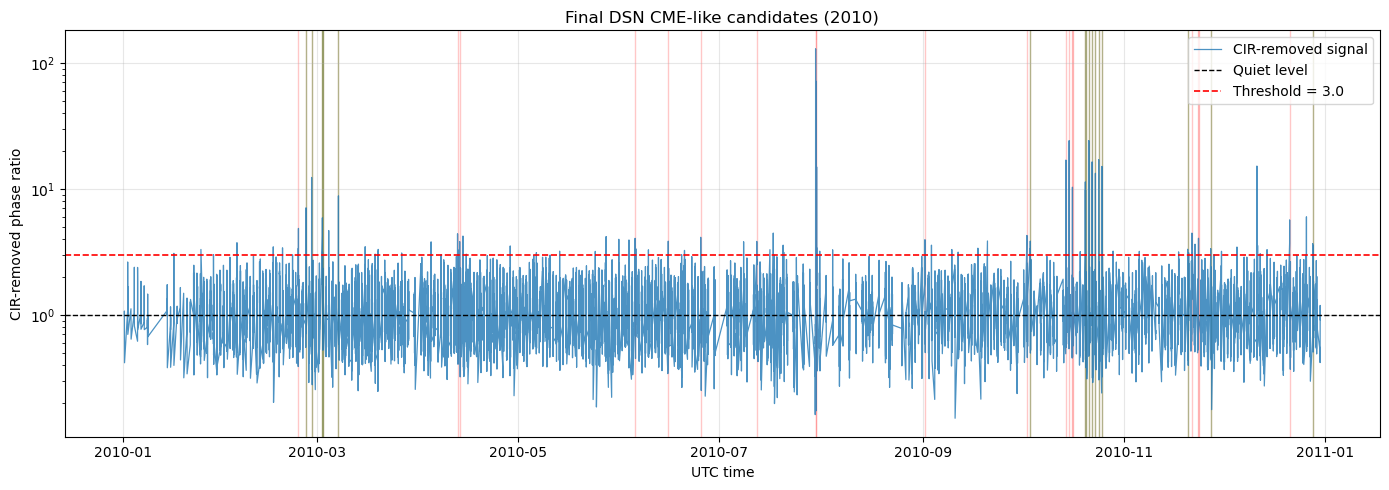

In [13]:
# ============================================================
# SECTION 9 — Final Candidate Visualisation
# ============================================================

fig, ax = plot_final_cme_candidates(
    windows_flagged,
    final_events,
    year=YEAR,
)

for _, e in final_events.iterrows():
    if e.get("cactus_crosses_p_point", False):
        ax.axvspan(
            e["start"],
            e["end"],
            color="green",
            alpha=0.3,
        )

plt.show()

if save_files:
    fig.savefig(
        FIG_FILE,
        dpi=300,
        bbox_inches="tight",
    )

    print("Saved:", FIG_FILE)

Supported events: 15
Unsupported events: 17
Supported duration: 0.6666666666666666
Supported peak: 9.81783420224592
Supported median signal: 6.409756839715314
Supported contrast: 1.3443557333461487
Unsupported duration: 0.5
Unsupported peak: 4.401308994604334
Unsupported median signal: 3.8597265928448223
Unsupported contrast: 1.180663549023026


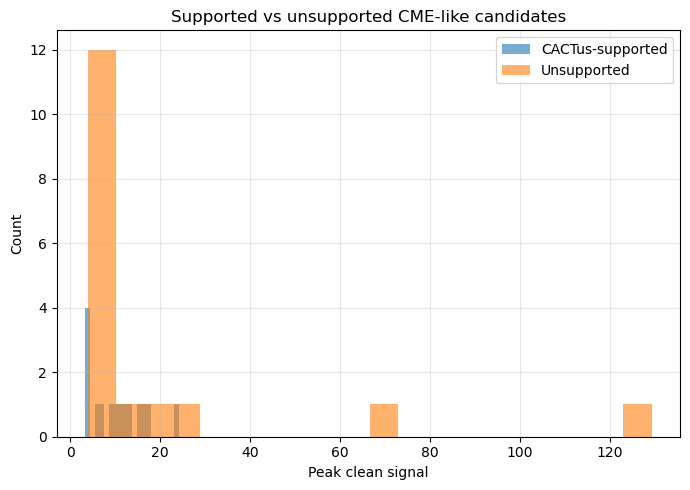

In [14]:
# ============================================================
# SECTION 10 — Supported vs Unsupported Candidate Diagnostics
# ============================================================

if "cactus_crosses_p_point" in final_events.columns:

    final_events["contrast"] = (
        final_events["peak_clean_signal"]
        / final_events["median_clean_signal"]
    )

    supported = final_events[
        final_events["cactus_crosses_p_point"] == True
    ].copy()

    unsupported = final_events[
        final_events["cactus_crosses_p_point"] == False
    ].copy()

    print("Supported events:", len(supported))
    print("Unsupported events:", len(unsupported))

    if len(supported) > 0:
        print("Supported duration:", supported["duration_hr"].median())
        print("Supported peak:", supported["peak_clean_signal"].median())
        print("Supported median signal:", supported["median_clean_signal"].median())
        print("Supported contrast:", supported["contrast"].median())

    if len(unsupported) > 0:
        print("Unsupported duration:", unsupported["duration_hr"].median())
        print("Unsupported peak:", unsupported["peak_clean_signal"].median())
        print("Unsupported median signal:", unsupported["median_clean_signal"].median())
        print("Unsupported contrast:", unsupported["contrast"].median())

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.hist(
        supported["peak_clean_signal"].dropna(),
        bins=20,
        alpha=0.6,
        label="CACTus-supported",
    )

    ax.hist(
        unsupported["peak_clean_signal"].dropna(),
        bins=20,
        alpha=0.6,
        label="Unsupported",
    )

    ax.set_xlabel("Peak clean signal")
    ax.set_ylabel("Count")
    ax.set_title("Supported vs unsupported CME-like candidates")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [15]:
# ============================================================
# SECTION 11 — Save Final Candidate Tables
# ============================================================

if save_files:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    final_events.to_csv(
        OUTPUT_FILE,
        index=False,
    )

    diagnostics_df.to_csv(
        CHECK_FILE,
        index=False,
    )

    print("Saved candidate table:", OUTPUT_FILE)
    print("Saved diagnostics table:", CHECK_FILE)